### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


## Agentic RAG with Langchain v1, Ollama, and FAISS
**Key Features:**
- Agent-based architecture with autonomous tool usage for document retrieval
- FAISS vector store for efficient semantic search across document embeddings
- Ollama integration with Qwen3 LLM and nomic-embed-text embeddings for local deployment
- Custom retrieval tool that finds and formats relevant document chunks with metadata
- Interactive chat interface with streaming responses and tool call visibility

In [21]:
# pip install -U langchain langchain-ollama, langchain-community langchain-core faiss-cpu
# ollama pull nomic-embed-text
# ollama pull qwen3

In [22]:
import os
import warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
warnings.filterwarnings("ignore")

from langfuse.langchain import CallbackHandler
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv


load_dotenv()
langfuce_trace = CallbackHandler()

In [23]:
# ============================================================================
# LLM & VECTOR STORE SETUP
# ============================================================================

# Ollama LLM with Qwen3
llm = ChatOllama(
    model="qwen3.5:4b", 
    base_url="http://localhost:11434"
)

# Ollama Embeddings
embeddings = OllamaEmbeddings(
    model="nomic-embed-text",
    base_url="http://localhost:11434"
)

# FAISS Vector Store (assumes data already exists from previous code)
db_name = "./../09. Vector Stores and Retrievals/health_supplements"
vector_store = FAISS.load_local(
    db_name,
    embeddings,
    allow_dangerous_deserialization=True
)

In [24]:
llm.invoke("Hello")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-05-29T14:06:29.094934246Z', 'done': True, 'done_reason': 'stop', 'total_duration': 50890198117, 'load_duration': 10298257140, 'prompt_eval_count': 11, 'prompt_eval_duration': 375621770, 'eval_count': 309, 'eval_duration': 39995914689, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--019e740e-0c1b-7501-ab70-24da2517dce6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 309, 'total_tokens': 320})

In [25]:
# ============================================================================
# VECTOR STORE VERIFICATION
# ============================================================================
print("\n🔍 Testing Vector Store Connection...")

# Test 1: Check collection info
doc_count = vector_store.index.ntotal
print(f"✓ Vector store found with {doc_count} documents")


# Test 2: Sample similarity search
test_query = "creatine"
results = vector_store.similarity_search(test_query, k=3)
print(f"\n✓ Sample search for '{test_query}':")

for i, doc in enumerate(results, 1):
    print(f"  {i}. Source: {doc.metadata.get('source', '?')} (Page {doc.metadata.get('page', '?')}): {doc.page_content[:100]}...")



🔍 Testing Vector Store Connection...
✓ Vector store found with 311 documents

✓ Sample search for 'creatine':
  1. Source: rag-dataset\gym supplements\1. Analysis of Actual Fitness Supplement.pdf (Page 0): acids than traditional protein sources. Its numerous benefits have made it a popular choice
for snac...
  2. Source: rag-dataset\gym supplements\1. Analysis of Actual Fitness Supplement.pdf (Page 1): Foods 2024, 13, 1424
2 of 21
and sports industry, evidence suggests that creatine can benefit not on...
  3. Source: rag-dataset\gym supplements\2. High Prevalence of Supplement Intake.pdf (Page 10): supplements such as creatine or beta-alanine were used only once a week, which cannot be eﬀective [9...


In [26]:
results

[Document(id='fd2726cd-009e-4ccf-b853-9fa852187c99', metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '', 'source': 'rag-dataset\\gym supplements\\1. Analysis of Actual Fitness Supplement.pdf', 'file_path': 'rag-dataset\\gym supplements\\1. Analysis of Actual Fitness Supplement.pdf', 'total_pages': 15, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-10-21T11:38:50+00:00', 'trapped': '', 'modDate': 'D:20241021113850Z', 'creationDate': '', 'page': 0}, page_content='acids than traditional protein sources. Its numerous benefits have made it a popular choice\nfor snacks and drinks among consumers [3]. Another widely embraced supplement is\ncaffeine, which is found in many sports and food supplements. Caffeine reduces perceived\neffort, minimizes fatigue and pain, and proves to be effective for endurance and high-\nintensity activities, which is the choice of consumers [4].\nCreatine monohydrate is another well-known supplement 

In [27]:
# ============================================================================
# RETRIEVAL TOOL
# ============================================================================
@tool()
def retrieve_context(query: str):
    """Retrieve relevant information for health related queries from the document to answer the query.
    
    """
    print(f"🔍 Searching: '{query}'")
    
    # Perform similarity search
    docs = vector_store.similarity_search(query, k=4)
    
    # Format for LLM
    content = "\n\n".join(
        f"Source: {doc.metadata.get("source", '?')} (Page {doc.metadata.get("page", "?")}: {doc.page_content})"
        for doc in docs
    )
    print(f"✓ Found {len(docs)} relevant chunks")
    return content


In [28]:
result = retrieve_context.invoke(
    "What is the use of BCAA?",
    config={"callbacks": [langfuce_trace]},
)
print(result)

🔍 Searching: 'What is the use of BCAA?'
✓ Found 4 relevant chunks
Source: rag-dataset\health supplements\2. Nutraceuticals research.pdf (Page 5: the food affecting its nutritional value, metabolism or level of
undesirable substances”.
They are further deﬁned as “food consisting of, isolated
from or produced from animals or their parts, except for
animals obtained by traditional breeding practices which
have been used for food production within the Union before
15 May 1997 and the food from those animals has a history of
safe food use within the Union”.
The same Regulation also includes “food used exclusively in
food supplements within the Union before 15 May 1997, where
it is intended to be used in foods other than food supplements
as deﬁned in point (a) of Article 2 of Directive 2002/46/EC”.
The same consideration might be considered valid for foods
that have a “history of safe food use in a third country”, suggest-
ing that the safety of the food in question has been conﬁrmed
from co

#### Create Tools and Agent

In [29]:
tools = [retrieve_context]
system_prompt = """
    You are a research assistant with a document retrieval tool.

    Tool:
    - retrieve_context: Search only document for the health related question

    Cite page numbers and reference document while writing the answer and be thorough.
"""

In [30]:
# Create the agentic RAG
rag_agent = create_agent(llm, tools, system_prompt=system_prompt)

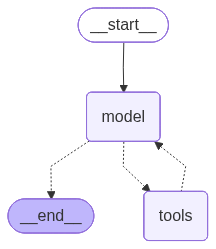

In [31]:
rag_agent

In [32]:
result = rag_agent.invoke({'messages': "What is the use of BCAA?"}, config={"callbacks": [langfuce_trace]})
result

🔍 Searching: 'use of BCAA benefits applications'
✓ Found 4 relevant chunks


{'messages': [HumanMessage(content='What is the use of BCAA?', additional_kwargs={}, response_metadata={}, id='d3a2d47b-a9fb-4d67-a3d5-6f46b62165ea'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-05-29T14:06:48.051335025Z', 'done': True, 'done_reason': 'stop', 'total_duration': 17298965416, 'load_duration': 440856367, 'prompt_eval_count': 331, 'prompt_eval_duration': 6113005024, 'eval_count': 85, 'eval_duration': 10658735530, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--019e740e-d95e-7450-81a5-ad90a91f2c7b-0', tool_calls=[{'name': 'retrieve_context', 'args': {'query': 'use of BCAA benefits applications'}, 'id': '7f689083-76da-40be-8d2a-b8c87b7bdc72', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 331, 'output_tokens': 85, 'total_tokens': 416}),
  ToolMessage(content='Source: rag-dataset\\health supplements\\2. Nutraceuticals research.pdf (Page 6: clini

In [33]:
result

{'messages': [HumanMessage(content='What is the use of BCAA?', additional_kwargs={}, response_metadata={}, id='d3a2d47b-a9fb-4d67-a3d5-6f46b62165ea'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-05-29T14:06:48.051335025Z', 'done': True, 'done_reason': 'stop', 'total_duration': 17298965416, 'load_duration': 440856367, 'prompt_eval_count': 331, 'prompt_eval_duration': 6113005024, 'eval_count': 85, 'eval_duration': 10658735530, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--019e740e-d95e-7450-81a5-ad90a91f2c7b-0', tool_calls=[{'name': 'retrieve_context', 'args': {'query': 'use of BCAA benefits applications'}, 'id': '7f689083-76da-40be-8d2a-b8c87b7bdc72', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 331, 'output_tokens': 85, 'total_tokens': 416}),
  ToolMessage(content='Source: rag-dataset\\health supplements\\2. Nutraceuticals research.pdf (Page 6: clini

In [34]:
result['messages'][-1].pretty_print()

================================== Ai Message ==================================

Based on the provided documents, there is **no specific information regarding the use of Branched-Chain Amino Acids (BCAAs)**. The available texts focus on general definitions of nutraceuticals, health claims, and functional foods, rather than detailing specific supplements like BCAAs.

To address your question generally based on standard health knowledge:

*   **Definition:** BCAAs are a group of three essential amino acids: **Leucine, Isoleucine, and Valine**.
*   **Primary Uses:** They are most commonly used by athletes and active individuals to:
    1.  **Prevent Muscle Soreness:** BCAAs are often marketed to help reduce muscle breakdown and soreness after exercise.
    2.  **Promote Muscle Recovery:** They are believed to aid in the repair of muscle tissue following physical exertion.
    3.  **Maintain Muscle Mass:** They may help prevent muscle protein breakdown during periods of intense training o

In [35]:
# ============================================================================
# QUERY FUNCTION
# ============================================================================
def ask(question: str):
    """Ask the agentic RAG a question."""
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print('='*60)
    
    for event in rag_agent.stream(
        {"messages": [{"role": "user", "content": question}]},
        stream_mode="values"
    ):
        msg = event["messages"][-1]
        
        # Show tool usage
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tc in msg.tool_calls:
                print("Tool Call: ")
                print(f"\n🔧 Using: {tc['name']} with {tc['args']}")
        
        # Show final answer
        elif hasattr(msg, 'content') and msg.content:
            print(f"\n💬 Answer:\n{msg.content}")

In [36]:
# ============================================================================
# TESTING
# ============================================================================
# Test basic retrieval
ask("how to gain muscle mass?")



Question: how to gain muscle mass?

💬 Answer:
how to gain muscle mass?
Tool Call: 

🔧 Using: retrieve_context with {'query': 'how to gain muscle mass'}
🔍 Searching: 'how to gain muscle mass'
✓ Found 4 relevant chunks

💬 Answer:
Source: rag-dataset\gym supplements\2. High Prevalence of Supplement Intake.pdf (Page 8: and strength gain among men. We detected more prevalent protein and creatine supplementation
among younger compared to older ﬁtness center users, whereas the opposite was found for vitamin
supplementation. Other authors made similar observations [23] and it might reﬂect the diﬀerent
training goals among age groups, i.e., more focus on strength and muscles among the younger and
more focus on health among the older age groups.
Comparable to other studies [4], we detected a positive correlation between training frequency
and supplement usage. Nevertheless, the correlation is weak and is deﬁnitely not a predictor at the
individual level. The subject with the highest supplement 

In [37]:
ask("tell me 3 facts about Earth?")


Question: tell me 3 facts about Earth?

💬 Answer:
tell me 3 facts about Earth?
Tool Call: 

🔧 Using: retrieve_context with {'query': 'Earth facts information'}
🔍 Searching: 'Earth facts information'
✓ Found 4 relevant chunks

💬 Answer:
Source: rag-dataset\health supplements\1. dietary supplements - for whom.pdf (Page 14: by the World Anti-Doping Agency [140].
Despite legal requirements, labels of dietary supplements cannot be treated as a source
of reliable information about the products’ contents. In North America, where the brain
health supplement market is developing rapidly, 10 out of 12 products contained non-)

Source: rag-dataset\gym supplements\2. High Prevalence of Supplement Intake.pdf (Page 7: Nutrients 2020, 12, 2595
8 of 13
education (i.e., registered dietitian or physician). The most prevalent answers were diﬀerent types of
ﬁtness instructor courses (13) and sport studies (5).
Figure 4. Indicated relevant information sources about supplements. Multiple answers were possi

In [38]:
# ============================================================================
# INTERACTIVE CHAT
# ============================================================================
def chat():
    """Start interactive chat with the agentic RAG."""
    print("\n🤖 Agentic RAG Chat - Type 'quit, q or exit' to exit")
    
    while True:
        question = input("\nYour question: ").strip()
        if question.lower() in ['quit', 'exit', 'q']:
            break
        if question:
            ask(question)

chat()


🤖 Agentic RAG Chat - Type 'quit, q or exit' to exit
